# Studio nel tempo della stabilità/volatilità delle parole nel corpus

Coeff di variazione: 

CV	Interpretazione
< 0.5	uso stabile

0.5–1	variabilità moderata

> 1	uso volatile


Parola: jouer
Media frequenza: 0.000831
Deviazione standard: 0.001120
Coefficiente di variazione (CV): 1.347


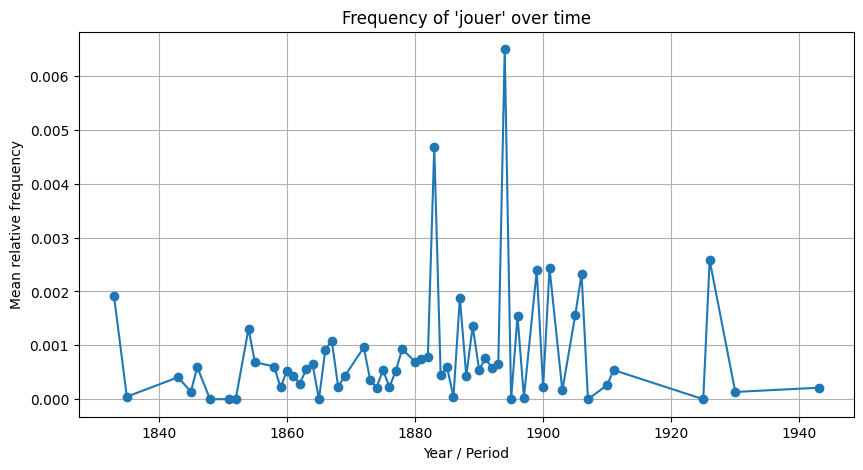

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETRI MODIFICABILI
# =========================

csv_path = "/tf-idf_personnages_ann.csv"
word = "jouer"          # parola da analizzare
start_year = 1800       # anno iniziale
end_year = 1945         # anno finale
bin_size = 1            # 1 = per anno, 10 = per decennio, ecc.

# =========================
# CARICAMENTO DATI
# =========================

df = pd.read_csv(csv_path)

# Estrai anno dal title (es: 1833_...)
df["year"] = df["title"].str.extract(r"(\d{4})").astype(int)

# Filtro anni
df = df[(df["year"] >= start_year) & (df["year"] <= end_year)]

# =========================
# CONTEGGIO FREQUENZE
# =========================

def word_frequency(text, word):
    tokens = text.split()
    if len(tokens) == 0:
        return 0
    return tokens.count(word) / len(tokens)

df["freq"] = df["text"].apply(lambda x: word_frequency(str(x), word))

# =========================
# CREAZIONE INTERVALLI
# =========================

if bin_size > 1:
    df["period"] = (df["year"] // bin_size) * bin_size
else:
    df["period"] = df["year"]

freq_by_period = df.groupby("period")["freq"].mean()

# =========================
# COEFFICIENTE DI VARIAZIONE
# =========================

mean_freq = freq_by_period.mean()
std_freq = freq_by_period.std()

cv = std_freq / mean_freq if mean_freq != 0 else np.nan

print(f"\nParola: {word}")
print(f"Media frequenza: {mean_freq:.6f}")
print(f"Deviazione standard: {std_freq:.6f}")
print(f"Coefficiente di variazione (CV): {cv:.3f}")

# =========================
# GRAFICO
# =========================

plt.figure(figsize=(10,5))

plt.plot(freq_by_period.index, freq_by_period.values, marker="o")

plt.title(f"Frequency of '{word}' over time")
plt.xlabel("Year / Period")
plt.ylabel("Mean relative frequency")

plt.grid(True)

plt.show()

## Versione con normalizzazione e filtro gender/type


--- ANALYSIS ---
Word: poupée
Gender filter: [1]
Type filter: [1]
Mean frequency: 0.001071
Standard deviation: 0.000774
Coefficient of variation: 0.723


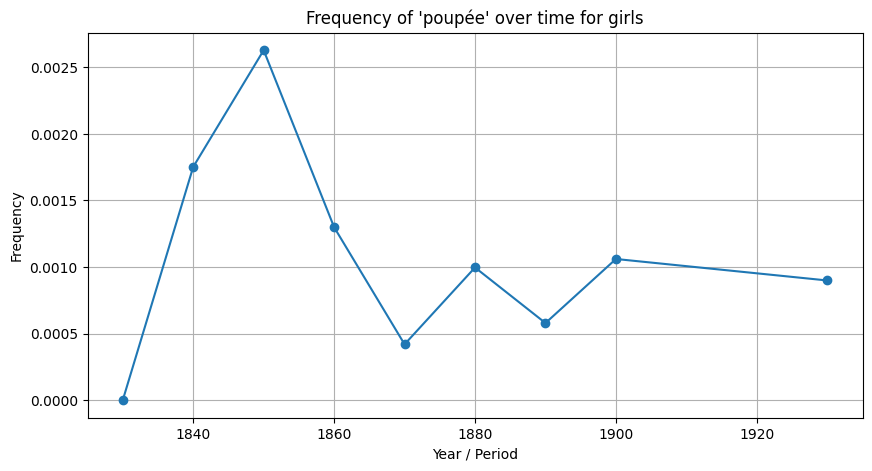

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETRI MODIFICABILI
# =========================

csv_path = "/tf-idf_personnages_ann.csv"

word = "poupée"

start_year = 1800
end_year = 1950

bin_size = 10   # 1=anno, 10=decennio ecc.

gender_filter = [1]   # oppure ["Female"]
type_filter = [1]     # oppure ["child"]

normalize = True   # True = frequenza relativa, False = conteggio assoluto

# =========================
# CARICAMENTO DATI
# =========================

df = pd.read_csv(csv_path)

# Estrazione anno dal title
df["year"] = df["title"].str.extract(r"(\d{4})").astype(int)

# =========================
# FILTRI
# =========================

df = df[
    (df["year"] >= start_year) &
    (df["year"] <= end_year) &
    (df["Gender"].isin(gender_filter)) &
    (df["type"].isin(type_filter))
].copy()

# =========================
# FUNZIONE FREQUENZA PAROLA
# =========================

def word_frequency(text, word):

    tokens = str(text).split()

    if len(tokens) == 0:
        return 0

    count = tokens.count(word)

    if normalize:
        return count / len(tokens)
    else:
        return count

df["freq"] = df["text"].apply(lambda x: word_frequency(x, word))

# =========================
# CREAZIONE PERIODI
# =========================

if bin_size > 1:
    df["period"] = (df["year"] // bin_size) * bin_size
else:
    df["period"] = df["year"]

# =========================
# AGGREGAZIONE
# =========================

if normalize:
    freq_series = df.groupby("period")["freq"].mean()
else:
    freq_series = df.groupby("period")["freq"].sum()

# =========================
# COEFFICIENTE VARIAZIONE
# =========================

mean_freq = freq_series.mean()
std_freq = freq_series.std()

cv = std_freq / mean_freq if mean_freq != 0 else np.nan

print("\n--- ANALYSIS ---")
print(f"Word: {word}")
print(f"Gender filter: {gender_filter}")
print(f"Type filter: {type_filter}")
print(f"Mean frequency: {mean_freq:.6f}")
print(f"Standard deviation: {std_freq:.6f}")
print(f"Coefficient of variation: {cv:.3f}")

# =========================
# GRAFICO
# =========================

plt.figure(figsize=(10,5))

plt.plot(freq_series.index, freq_series.values, marker="o")

plt.title(f"Frequency of '{word}' over time for girls")
plt.xlabel("Year / Period")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# Distribuzione di genere autrici/autori nel tempo

        Male authors  Female authors
period                              
1833               0               5
1835               0               5
1843               5               5
1845               5               0
1846               5               0
1848               0               5
1851               0               5
1852               0               5
1854               4               5
1855               5               0
1858               0              20
1859               0               5
1860               0              10
1861               0               5
1862               0              10
1863               0              10
1864               5               5
1865               5               0
1866               5              15
1867              14              20
1868               0               5
1869               0               5
1872               0               5
1873               5              15
1874               0              14
1

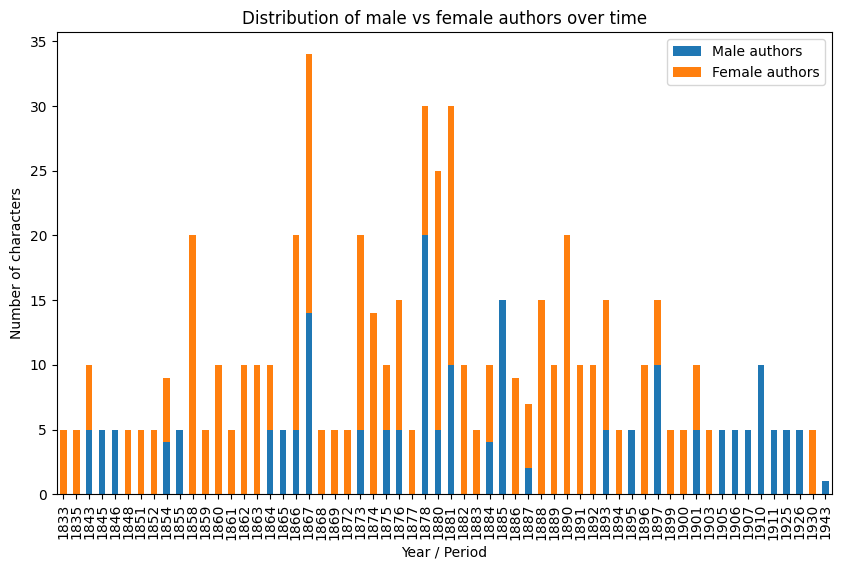

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# PARAMETRI
# =========================

csv_path = "tf-idf_personnages_ann.csv"
bin_size = 1   # 1=anno, 10=decennio

# =========================
# CARICAMENTO DATI
# =========================

df = pd.read_csv(csv_path)

# Estrazione anno dal titolo
df["year"] = df["title"].str.extract(r"(\d{4})").astype(int)

# =========================
# CREAZIONE PERIODI
# =========================

if bin_size > 1:
    df["period"] = (df["year"] // bin_size) * bin_size
else:
    df["period"] = df["year"]

# =========================
# CONTEGGIO
# =========================

books = df.drop_duplicates("title")

counts = books.groupby(["period", "author_gender"]).size().unstack(fill_value=0)

#counts = df.groupby(["period", "author_gender"]).size().unstack(fill_value=0)

counts.columns = ["Male authors", "Female authors"]

print(counts)

# =========================
# GRAFICO
# =========================

counts.plot(kind="bar", stacked=True, figsize=(10,6))

plt.xlabel("Year / Period")
plt.ylabel("Number of characters")
plt.title("Distribution of male vs female authors over time")

plt.show()

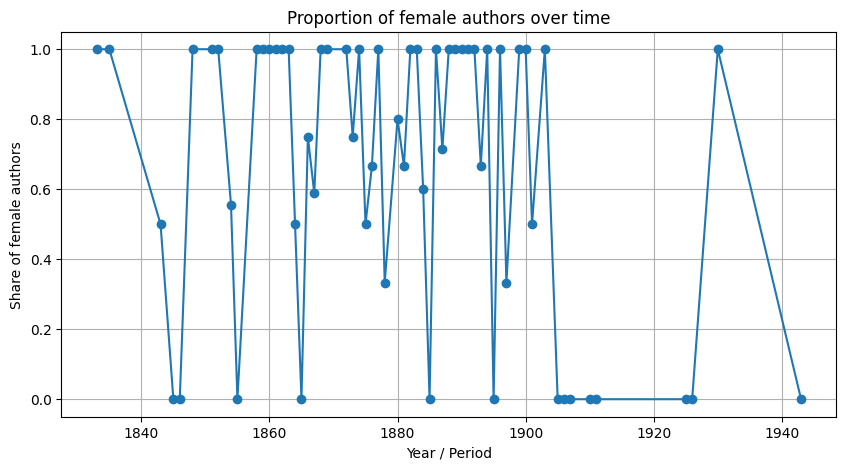

In [19]:
totals = counts.sum(axis=1)

female_share = counts["Female authors"] / totals

plt.figure(figsize=(10,5))

plt.plot(female_share.index, female_share.values, marker="o")

plt.xlabel("Year / Period")
plt.ylabel("Share of female authors")

plt.title("Proportion of female authors over time")

plt.grid(True)

plt.show()

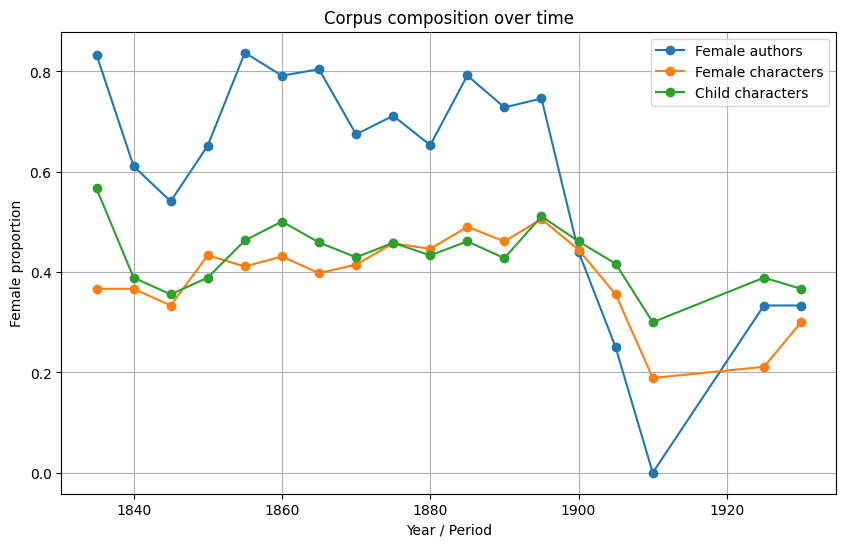

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# PARAMETRI
# =========================

csv_path = "/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Memoire/Github_tesi/tf-idf_personnages_ann.csv"
bin_size = 5   # 1=anno, 10=decennio

# =========================
# CARICAMENTO DATI
# =========================

df = pd.read_csv(csv_path)

# estrazione anno
df["year"] = df["title"].str.extract(r"(\d{4})").astype(int)

# =========================
# CREAZIONE PERIODI
# =========================

if bin_size > 1:
    df["period"] = (df["year"] // bin_size) * bin_size
else:
    df["period"] = df["year"]

# =========================
# 1️⃣ AUTORI VS AUTRICI
# =========================

books = df.drop_duplicates("title")

authors = books.groupby("period")["author_gender"].mean()
authors = authors.rolling(3, center=True).mean() # smooth temporale (rolling mean) per rendere le curve meno rumorose

# mean funziona perché
# 0 = male
# 1 = female

# =========================
# 2️⃣ PERSONAGGI FEMMINILI
# =========================

characters = df.groupby("period")["Gender"].apply(
    lambda x: (x == 1).mean()
)
characters = characters.rolling(3, center=True).mean() # smooth temporale (rolling mean) per rendere le curve meno rumorose

# =========================
# 3️⃣ PERSONAGGI BAMBINI
# =========================

children = df.groupby("period")["type"].apply(
    lambda x: (x == 1).mean()
)
children = children.rolling(3, center=True).mean() # smooth temporale (rolling mean) per rendere le curve meno rumorose

# =========================
# GRAFICO
# =========================

plt.figure(figsize=(10,6))

plt.plot(authors.index, authors.values, marker="o", label="Female authors")

plt.plot(characters.index, characters.values, marker="o", label="Female characters")

plt.plot(children.index, children.values, marker="o", label="Child characters")

plt.xlabel("Year / Period")
plt.ylabel("Female proportion")

plt.title("Corpus composition over time")

plt.legend()

plt.grid(True)

plt.show()

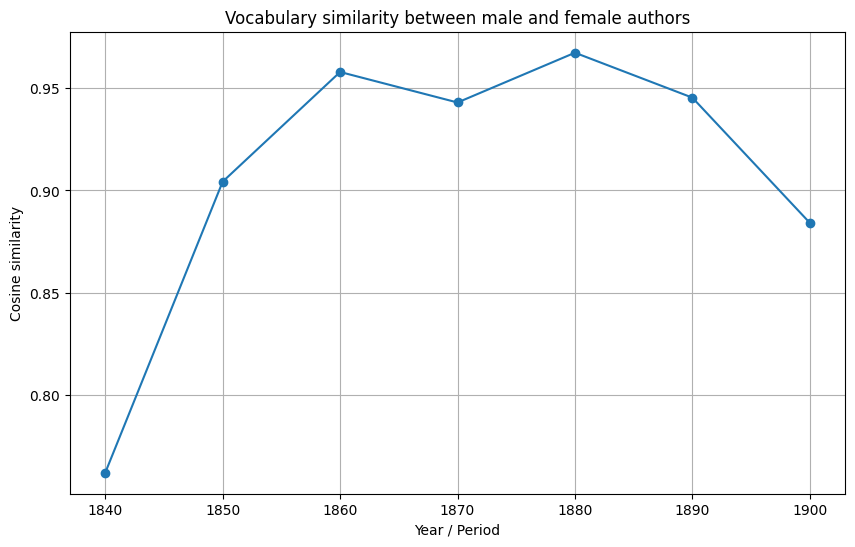

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# PARAMETRI
# =========================

csv_path = "/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Memoire/Github_tesi/tf-idf_personnages_ann.csv"

bin_size = 10

# =========================
# CARICAMENTO DATI
# =========================

df = pd.read_csv(csv_path)

df["year"] = df["title"].str.extract(r"(\d{4})").astype(int)

# =========================
# CREAZIONE PERIODI
# =========================

if bin_size > 1:
    df["period"] = (df["year"] // bin_size) * bin_size
else:
    df["period"] = df["year"]

# =========================
# COSTRUZIONE VOCABOLARIO
# =========================

vocab = set()

for text in df["text"]:
    vocab.update(str(text).split())

vocab = sorted(vocab)

word_index = {w:i for i,w in enumerate(vocab)}

# =========================
# FUNZIONE VETTORE FREQUENZE
# =========================

def build_vector(texts):

    counter = Counter()

    for t in texts:
        counter.update(str(t).split())

    vec = np.zeros(len(vocab))

    for w,c in counter.items():
        if w in word_index:
            vec[word_index[w]] = c

    return vec

# =========================
# SIMILARITÀ PER PERIODO
# =========================

periods = sorted(df["period"].unique())

similarities = []

for p in periods:

    sub = df[df["period"] == p]

    male = sub[sub["author_gender"] == 0]
    female = sub[sub["author_gender"] == 1]

    if len(male) == 0 or len(female) == 0:
        similarities.append(np.nan)
        continue

    vec_m = build_vector(male["text"])
    vec_f = build_vector(female["text"])

    sim = cosine_similarity([vec_m],[vec_f])[0][0]

    similarities.append(sim)

# =========================
# GRAFICO
# =========================

plt.figure(figsize=(10,6))

plt.plot(periods, similarities, marker="o")

plt.xlabel("Year / Period")
plt.ylabel("Cosine similarity")

plt.title("Vocabulary similarity between male and female authors")

plt.grid(True)

plt.show()